In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt



In [2]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')


In [3]:
data

,Date,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,1-Apr-23,23286.87,5.633309,0.679596,98.804118,0.988493,12.778676,0.317022,34.709118,43047497.21,46889,251417.5882,149.154412,49209296.38,43.460147,6161799.12
1,1-Aug-23,23677.76,7.364028,0.471457,95.325628,0.820870,7.653198,0.066296,35.626903,50313422.69,59988,122458.1053,3983.046559,56692531.22,40.117105,6379108.66
2,1-Dec-22,20755.21,5.066298,0.644504,97.453779,0.917099,10.162252,0.093053,34.349733,38831073.14,41009,244848.5649,2167.549618,44311619.79,35.898473,5480546.64
3,1-Feb-23,21880.87,5.382316,0.792096,98.227500,1.016471,12.823051,0.202574,35.099449,39888353.28,43346,241229.6471,22.955882,45724214.07,42.006801,5835860.74
4,1-Jan-23,20811.78,5.389850,0.704850,98.747444,0.939248,10.303647,0.164361,36.835038,36907578.16,40927,241561.7820,0.000000,42734990.38,37.557368,5827412.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,9-Mar-23,23350.58,5.057684,0.742757,98.266507,1.002463,12.961728,0.197096,35.234963,41676401.56,45812,249644.5074,6.106618,47851202.93,41.218088,6174801.32
362,9-May-23,22459.26,5.047216,0.716923,99.384286,1.012454,9.975018,0.304176,34.966886,42117368.21,45766,249021.0330,447.410256,48156570.69,42.919341,6039202.57
363,9-Nov-22,17475.45,3.133588,0.517557,97.921145,0.927290,11.786832,0.102977,35.045382,29272509.30,39918,218947.5573,1449.561069,33761716.22,38.948511,4489206.83
364,9-Oct-22,16437.81,3.316680,0.559040,98.747840,0.959960,10.710440,0.130640,35.621360,30127950.12,34459,216222.9000,694.732000,34672216.32,37.295080,4544265.80


In [4]:
# Grouping by 'STARTTIME_DATE' and 'Thana', and calculating the average for each column
grouped_data = data.groupby(['STARTTIME_DATE', 'Thana']).mean().reset_index()

# Display the result
print(grouped_data)

     STARTTIME_DATE  Thana  AVG_NO_USER  AVG_USR_THRPUT_DL  AVG_USR_THRPUT_UL  \
0          1/1/2023  Area1    78.239774           5.389850           0.704850   
1          1/1/2023  Area2    40.092098           6.331246           0.567279   
2          1/1/2023  Area3    48.284056           6.219111           0.573056   
3          1/1/2023  Area4    47.362346           5.272160           0.526049   
4         1/10/2023  Area1    78.858750           5.130257           0.682647   
...             ...    ...          ...                ...                ...   
1459       9/8/2022  Area4    41.478472           3.766181           0.396319   
1460       9/9/2022  Area1    70.643839           3.410580           0.611473   
1461       9/9/2022  Area2    41.047216           3.992392           0.419137   
1462       9/9/2022  Area3    44.715769           4.339167           0.439103   
1463       9/9/2022  Area4    42.019931           3.592917           0.389306   

           CSSR  DL_256QAM_

C:\Users\HP\AppData\Local\Temp\ipykernel_58136\4032163902.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  grouped_data = data.groupby(['STARTTIME_DATE', 'Thana']).mean().reset_index()


In [5]:
grouped_data.to_csv('Thanawise_data.csv', index=False)

In [6]:
# Assuming your original data is in a pandas DataFrame called `data`
# Group data by 'Thana'
thana_groups = data.groupby('Thana')

In [7]:
# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, :])
    return np.array(X), np.array(Y)

# Function to build and train LSTM model with given hyperparameters
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Hyperparameters to be used (from the best run in your previous code)
units = 100
dropout_rate = 0.2
batch_size = 64
epochs = 100
optimizer = 'adam'

In [8]:
# Store MSE for each Thana
mse_dict = {}

Processing Thana: Area1
Epoch 1/100
1256/1256 [==============================] - 23s 6ms/step - loss: 0.0384 - val_loss: 0.0349 - lr: 0.0010
Epoch 2/100
1256/1256 [==============================] - 8s 6ms/step - loss: 0.0370 - val_loss: 0.0350 - lr: 0.0010
Epoch 3/100
1256/1256 [==============================] - 8s 6ms/step - loss: 0.0370 - val_loss: 0.0357 - lr: 0.0010
Epoch 4/100
1256/1256 [==============================] - 9s 7ms/step - loss: 0.0370 - val_loss: 0.0354 - lr: 0.0010
Epoch 5/100
1256/1256 [==============================] - 7s 6ms/step - loss: 0.0370 - val_loss: 0.0352 - lr: 0.0010
Epoch 6/100
1256/1256 [==============================] - 8s 6ms/step - loss: 0.0370 - val_loss: 0.0349 - lr: 0.0010
Epoch 7/100
1256/1256 [==============================] - 8s 6ms/step - loss: 0.0370 - val_loss: 0.0354 - lr: 0.0010
Epoch 8/100
1256/1256 [==============================] - 8s 6ms/step - loss: 0.0370 - val_loss: 0.0352 - lr: 0.0010
Epoch 9/100
1256/1256 [========================

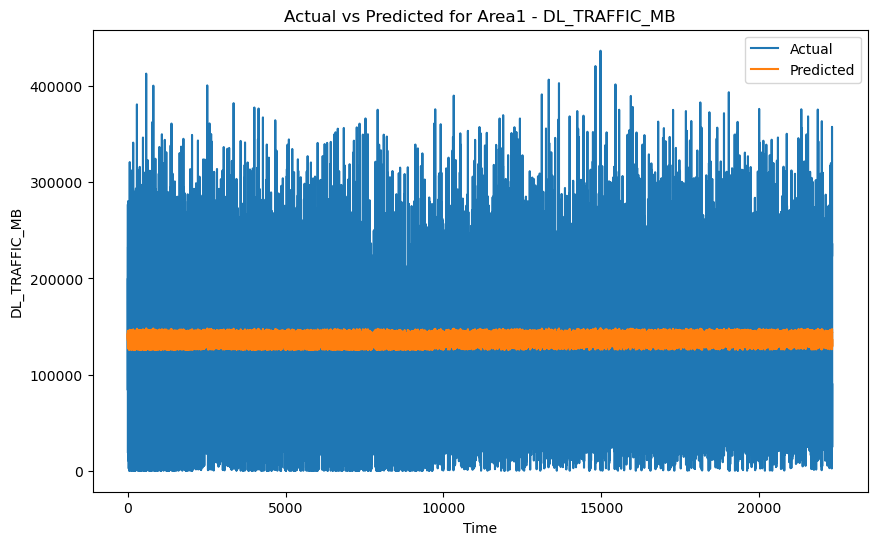

Processing Thana: Area2
Epoch 1/100
1270/1270 [==============================] - 29s 14ms/step - loss: 0.0272 - val_loss: 0.0302 - lr: 0.0010
Epoch 2/100
1270/1270 [==============================] - 10s 8ms/step - loss: 0.0264 - val_loss: 0.0307 - lr: 0.0010
Epoch 3/100
1270/1270 [==============================] - 8s 6ms/step - loss: 0.0264 - val_loss: 0.0302 - lr: 0.0010
Epoch 4/100
1270/1270 [==============================] - 10s 8ms/step - loss: 0.0264 - val_loss: 0.0303 - lr: 0.0010
Epoch 5/100
1270/1270 [==============================] - 9s 7ms/step - loss: 0.0264 - val_loss: 0.0305 - lr: 0.0010
Epoch 6/100
1270/1270 [==============================] - 12s 9ms/step - loss: 0.0264 - val_loss: 0.0304 - lr: 0.0010
Epoch 7/100
1270/1270 [==============================] - 14s 11ms/step - loss: 0.0264 - val_loss: 0.0300 - lr: 0.0010
Epoch 8/100
1270/1270 [==============================] - 9s 7ms/step - loss: 0.0264 - val_loss: 0.0302 - lr: 0.0010
Epoch 9/100
1270/1270 [==================

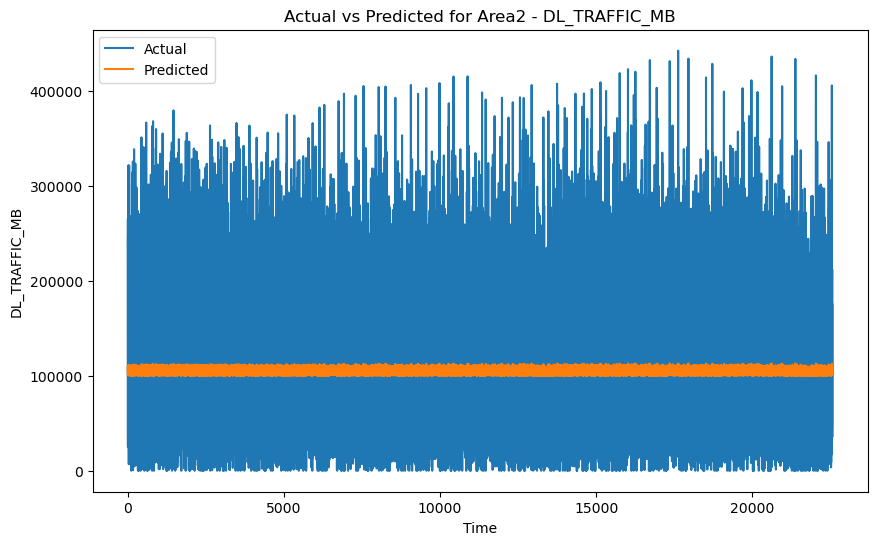

Processing Thana: Area3
Epoch 1/100
815/815 [==============================] - 25s 16ms/step - loss: 0.0368 - val_loss: 0.0387 - lr: 0.0010
Epoch 2/100
815/815 [==============================] - 9s 11ms/step - loss: 0.0350 - val_loss: 0.0382 - lr: 0.0010
Epoch 3/100
815/815 [==============================] - 6s 7ms/step - loss: 0.0349 - val_loss: 0.0386 - lr: 0.0010
Epoch 4/100
815/815 [==============================] - 5s 7ms/step - loss: 0.0349 - val_loss: 0.0384 - lr: 0.0010
Epoch 5/100
815/815 [==============================] - 8s 9ms/step - loss: 0.0349 - val_loss: 0.0385 - lr: 0.0010
Epoch 6/100
640/815 [======================>.......] - ETA: 1s - loss: 0.0347

KeyboardInterrupt: 

In [9]:
# Iterate over each Thana's data
for thana, group in thana_groups:
    print(f'Processing Thana: {thana}')

    # Preparing data for 'DL_TRAFFIC_MB'
    feature = 'DL_TRAFFIC_MB'
    thana_data = group[[feature]].values

    # Normalize the 'DL_TRAFFIC_MB' data
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(thana_data)

    # Split the data into training and test sets (80% train, 20% test)
    train_size = int(len(scaled_data) * 0.8)
    train, test = scaled_data[:train_size], scaled_data[train_size:]

    # Create dataset for LSTM (look_back=1)
    X_train, y_train = create_dataset(train, look_back=1)
    X_test, y_test = create_dataset(test, look_back=1)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

    # Train the LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Inverse scaling for the predictions and the actual test data
    test_predict = scaler.inverse_transform(test_predict)
    y_test_inverse = scaler.inverse_transform(y_test)

    # Calculate MSE
    mse = mean_squared_error(y_test_inverse, test_predict)
    mse_dict[thana] = mse
    print(f'Thana: {thana}, MSE: {mse}')

    # Plot the results for each Thana
    plt.figure(figsize=(10, 6))
    plt.plot(y_test_inverse, label='Actual')
    plt.plot(test_predict, label='Predicted')
    plt.title(f'Actual vs Predicted for {thana} - {feature}')
    plt.xlabel('Time')
    plt.ylabel(feature)
    plt.legend()
    plt.show()